# LSTM for Time-Series Forecasting

*From naive baselines to learned recurrence*

## Welcome

Now we move to **learned** models — neural networks that read the 24-hour input window one hour at a time and update an internal **state** as they go. The model we study in this notebook is the workhorse of sequence modelling for the past decade: the **LSTM** (Long Short-Term Memory).

**The big questions for this notebook:**

1. *Why move beyond naive?* — naive forecasters do not learn the interaction between target history, wind, weather and time-of-day. A learned model can.
2. *What is recurrence?* — how does a network read a sequence step by step and carry information forward?
3. *Why LSTM specifically?* — the plain RNN has a well-known **vanishing-gradient** problem on long sequences. LSTM was designed to fix it via **gates**.
4. *When do we stop training?* — neural networks happily overfit given enough epochs. **EarlyStopping** is the standard practical answer; this notebook spells out how it works and why it matters extra for time-series.

**By the end of this notebook** you will have:

1. Built and trained an **LSTM(32)** forecaster on PM2.5 at *h* = 1 and inspected its training curve.
2. Understood **EarlyStopping** — `patience`, `restore_best_weights`, and why monitoring validation loss is the right signal for time-series models.
3. Swept the LSTM across **six settings** (PM2.5 / O&#8323; &times; *h* ∈ {1, 6, 12}) and seen where it beats the naive ceiling from NB2 — and where it cannot.

---
## 1. Why move beyond naive?

Persistence and seasonal-naive each apply **one fixed rule** to one feature (the target itself). Anything else in the input window — wind, temperature, the daily cycle, NO&#8322; as a combustion proxy — is ignored.

A learned model has access to the entire 24-hour, 15-feature window and can discover, on its own, things like:

- *"When the wind has been blowing from the south for the last 6 hours, raise the PM2.5 forecast."*
- *"It is 11 AM on a sunny day in July — start ramping the O&#8323; forecast even if the past hour was still low."*
- *"PM2.5 has been climbing for three hours straight — extrapolate the trend, don't just persist."*

Naive rules cannot express any of this. The question is **how much of this signal a learned model can actually capture**, and at what cost in complexity and training time. We will measure the answer in §7, side by side with the naive numbers from NB2.


---
## 2. Recurrence — reading a sequence one step at a time

**Analogy.** Imagine you are reading a paragraph one word at a time. After each word, you update a **mental summary** of what you have read so far. By the end of the paragraph that summary is your understanding of the whole text. You did not store every word; you stored a running abstraction.

A **recurrent neural network (RNN)** does exactly this. At every time-step *t* it has:

- An **input** **x**<sub>t</sub> — the features at hour *t* (PM2.5, wind, temperature, &hellip; 15 numbers in our case).
- A **hidden state** **h**<sub>t−1</sub> — the running summary carried over from the previous step.
- An **update rule** **h**<sub>t</sub> = *f*(**x**<sub>t</sub>, **h**<sub>t−1</sub>) — a small neural-network block (with trainable weights) that combines the two.

After the last step (*t* = *T* = 24) the final hidden state **h**<sub>24</sub> is the model's *summary of the whole window*. We pass it through one **Dense layer** to produce the forecast *ŷ*(*t*+*h*).

Visually (the same RNN cell unrolled across time, hidden state flowing left-to-right):

```
  x_1     x_2     x_3      ...      x_T
   |       |       |                 |
   v       v       v                 v
 [RNN] -> [RNN] -> [RNN] -> ... -> [RNN] -> Dense -> y_hat
   h_1     h_2     h_3              h_T
```

Two important properties:

- The **same** RNN cell (same weights) is applied at every time-step. If we want to read a longer window we just unroll for more steps — no extra parameters.
- The hidden state is the **only** carrier of past information. If something at hour 1 needs to influence the forecast at hour 24, it has to survive **23 update steps** without being overwritten.

---
## 3. Why plain RNNs struggle — vanishing and exploding gradients

The plain RNN above (one weight matrix, one hidden state) has a famous problem: **it forgets**. During training the loss flows **backwards through time** and gets multiplied by the same recurrent weights at every step. Over many steps that repeated multiplication amplifies tiny imbalances:

- If the recurrent weights are smaller than ≈1 in magnitude, the gradient shrinks toward zero — the **vanishing-gradient** problem. The training signal from far-back time-steps never reaches the early weights, so the model cannot learn long-range dependencies.
- If they are larger than ≈1, the gradient grows uncontrollably — the **exploding-gradient** problem. Updates become huge and training diverges.

Both effects get worse the longer the input sequence. For a 24-hour window plain RNNs are borderline; for week-long sequences they are essentially unusable.

**LSTM** (1997) was designed to mitigate this. It keeps the recurrence idea but adds **gates** — small learned switches that decide what to keep, what to forget and what to overwrite at each step. The gates create a *gradient highway* through which the loss signal can travel back across many more time-steps than in a plain RNN.

---
## 4. LSTM — three gates, two states

**Analogy.** Imagine your running summary is in two notebooks: a small **scratch pad** for the immediate moment, and a **long-term notebook** for things that matter further in the past. At each step you do three things, controlled by three small learned switches (the **gates**):

- **Forget gate** (*f*<sub>t</sub>) — *"What do I cross out from the long-term notebook?"* Looks at the current input and decides which old facts are no longer relevant.
- **Input gate** (*i*<sub>t</sub>) — *"What new information do I write into the long-term notebook?"* Looks at the current input and decides what's worth remembering for later.
- **Output gate** (*o*<sub>t</sub>) — *"What part of the long-term notebook do I expose to the current step?"* Decides which long-term facts matter **right now**.

Concretely the LSTM cell maintains:

- **c**<sub>t</sub> — the **cell state**, the long-term notebook.
- **h**<sub>t</sub> — the **hidden state**, the scratch pad exposed to the next step and (eventually) to the Dense head.

Each gate is a small neural network (σ of *W*·**x**<sub>t</sub> + *U*·**h**<sub>t−1</sub>) producing a vector in [0, 1] that **multiplies** parts of the cell state — element by element. Multiplication by 1 = "keep", by 0 = "erase". Because the cell state passes through these gated multiplications **without** being squashed by a non-linearity at every step, the gradient can flow back through it with much less vanishing than in a plain RNN. That is the key insight.

From a user's perspective, all of that is **one line in Keras**: `layers.LSTM(32)`. Internally it's three gates and two state vectors per time-step, each of size 32, with a few thousand trainable parameters.

---
## 5. Building and training a first LSTM

Let's build a **small LSTM** and train it on PM2.5 at *h* = 1 — the easiest of the six settings (strong autocorrelation, persistence already at MAE ≈10). The architecture is intentionally minimal: one LSTM layer with 32 units, one Dense head producing a single number.

We'll use the same data pipeline as NB1: load + wind + cyclic + windows + chronological split + train-only standardisation.

In [1]:
import os, sys, time, gc
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import keras
from keras import layers

import forecasting_utils as fu

SEED = 0
T    = 24      # window length in hours

# -- data pipeline (same chain as NB1) --
df = fu.load_clean_station("Nongzhanguan")
df = fu.add_wind_components(df).dropna(subset=["wind_u", "wind_v"]).reset_index(drop=True)
df = fu.add_cyclic_features(df)
print(f"Rows after preprocessing : {len(df):,}")


Rows after preprocessing : 33,114


In [2]:
# A reusable helper: build windows, split, standardise.
# Returns the standardised arrays plus the y-scaler so we can invert
# predictions back to micrograms before scoring.
def prep_data(target: str, h: int):
    feats = fu.features_min(target)
    Xw, yw = fu.make_windows(df, feats, target_col=target, T=T, h=h)
    X_tr, y_tr, X_va, y_va, X_te, y_te = fu.chronological_split(Xw, yw)
    sx, sy = fu.fit_scalers(X_tr, y_tr)
    Xs_tr, Xs_va, Xs_te = fu.scale_X(X_tr, sx), fu.scale_X(X_va, sx), fu.scale_X(X_te, sx)
    ys_tr = sy.transform(y_tr.reshape(-1, 1)).flatten().astype(np.float32)
    ys_va = sy.transform(y_va.reshape(-1, 1)).flatten().astype(np.float32)
    return (Xs_tr, ys_tr, Xs_va, ys_va, Xs_te, y_te, sy, len(feats))

def metrics(y_true, y_pred):
    return {"MAE":  float(mean_absolute_error(y_true, y_pred)),
            "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "R2":   float(r2_score(y_true, y_pred))}


In [ ]:
# --- build the LSTM ---
def build_lstm(T, n_feat, units=32):
    return keras.Sequential([
        layers.Input(shape=(T, n_feat)),
        layers.LSTM(units),
        layers.Dense(1),
    ])

# Train on PM2.5, h=1
Xs_tr, ys_tr, Xs_va, ys_va, Xs_te, y_te, sy, n_feat = prep_data("PM2.5", h=1)

keras.utils.set_random_seed(SEED)
model = build_lstm(T, n_feat, units=32)
model.summary(print_fn=lambda s: print(s) if s.strip() else None)

About **6,200 trainable parameters** for the whole LSTM(32) — tiny by deep-learning standards (typical CNNs and Transformers have millions). Most of them sit in the LSTM cell's eight weight matrices (four gates &times; input + hidden), the Dense head adds 33 more.

Now train. We use:
- **Adam** optimiser at default learning rate 10⁻³ — robust default.
- **MSE loss** on the standardised target — the default choice for regression (penalises large errors quadratically).
- **EarlyStopping** on validation loss with patience 4 — stops automatically when val loss has not improved for 4 epochs and restores the best-so-far weights. Up to 20 epochs.
- **Batch size 64** — small enough for fast iteration on CPU.

In [4]:
# Track both the training loss (MSE) and an additional metric (MAE)
# on every epoch — for both train and validation sets.
model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse",
              metrics=["mae"])
es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=4,
                                   restore_best_weights=True)

t0 = time.time()
history = model.fit(Xs_tr, ys_tr, validation_data=(Xs_va, ys_va),
                    epochs=20, batch_size=64, verbose=0, callbacks=[es])
train_time = time.time() - t0

# Evaluate on the held-out test set, in original micrograms/m^3
yp = sy.inverse_transform(model.predict(Xs_te, verbose=0).reshape(-1, 1)).flatten()
scores = metrics(y_te, yp)
print(f"Trained {len(history.history['loss'])} epochs in {train_time:.1f}s")
print(f"Test MAE  : {scores['MAE']:6.2f}  ug/m^3")
print(f"Test RMSE : {scores['RMSE']:6.2f}  ug/m^3")
print(f"Test R^2  : {scores['R2']:+.3f}")
print(f"\nBaseline (persistence) MAE was 10.11, R^2 = 0.96")

Trained 12 epochs in 12.6s
Test MAE  :   9.82  ug/m^3
Test RMSE :  16.28  ug/m^3
Test R^2  : +0.964

Baseline (persistence) MAE was 10.11, R^2 = 0.96


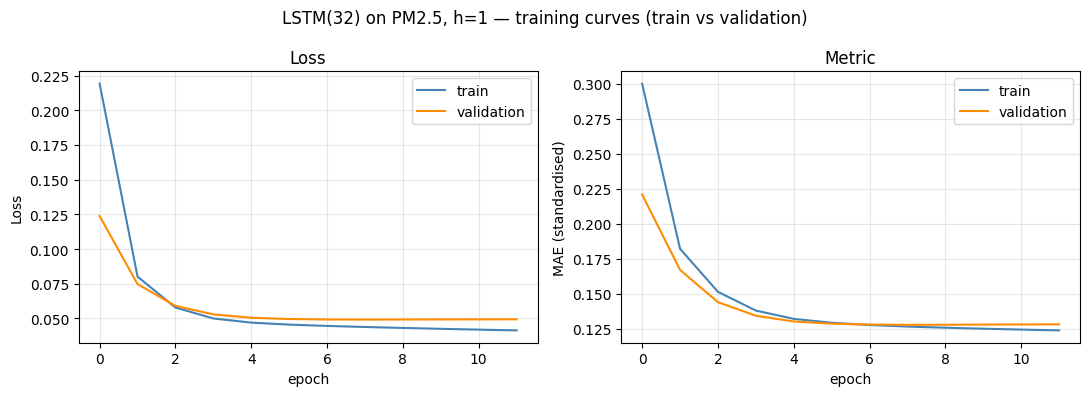

In [5]:
# Two training curves: MSE loss (left) and MAE metric (right),
# both on train and validation. The MAE values are in standardised
# space (target was scaled), but their *shape* is informative.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(history.history["loss"],     label="train",      color="steelblue")
ax1.plot(history.history["val_loss"], label="validation", color="darkorange")
ax1.set_xlabel("epoch"); ax1.set_ylabel("Loss")
ax1.set_title("Loss"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(history.history["mae"],     label="train",      color="steelblue")
ax2.plot(history.history["val_mae"], label="validation", color="darkorange")
ax2.set_xlabel("epoch"); ax2.set_ylabel("MAE (standardised)")
ax2.set_title("Metric"); ax2.legend(); ax2.grid(alpha=0.3)

fig.suptitle("LSTM(32) on PM2.5, h=1 — training curves (train vs validation)")
plt.tight_layout(); plt.show()

After about four epochs **train loss continues to fall while validation loss plateaus** — the classic mild over-fitting signal. The MAE curve tells the same story (it is in standardised units here, since the target was scaled).

Notice the training stopped well before the requested 20 epochs — that is **EarlyStopping** doing its job. The next section explains how.

---
## 6. EarlyStopping — when to stop training

**The problem.** With deep neural networks, train loss keeps falling almost indefinitely — given enough capacity, every extra epoch the model can squeeze a bit more out of the *training set*. But that does not mean the model gets better at predicting *unseen* data. After a while the model starts memorising training-set noise instead of generalisable patterns: **it overfits**.

**The signal.** Train loss is unreliable for deciding when to stop — for a sufficiently flexible model like a neural network it almost always points down. **Validation loss is the indicator we care about**: it goes down while the model is learning real structure, and turns flat (or rises) when the model starts overfitting.

**The callback.** Keras' `EarlyStopping` watches val loss and stops training automatically. Two parameters that matter most:

```python
keras.callbacks.EarlyStopping(
    monitor="val_loss",       # what to watch
    patience=4,                # epochs without improvement before stopping
    restore_best_weights=True, # roll back to the lowest-val-loss weights
)
```

- **`patience=4`** means *"if val loss does not improve for 4 consecutive epochs, stop".* Larger patience gives the model more chances to escape a small plateau; smaller patience stops more aggressively.
- **`restore_best_weights=True`** is critical. Without it, the model keeps the *last* set of weights — which is already past the optimum (the model trained `patience` extra epochs after the best point). With it, the best-so-far weights are restored, so we keep the genuinely best version of the model.

**Why it matters extra for time-series.** Our chronological split means the validation set is **genuinely the future** — the model has never seen it during training. A drop in val loss is therefore a clean estimate of generalisation. EarlyStopping on val loss is one of the most reliable signals you have for knowing when *the model is done learning the past in a way that transfers to the future*.

---
## 7. LSTM across all six settings

Recall the forecasting setup: we predict one of two **targets** (PM2.5 or O&#8323;) at one of three **forecast horizons** (1, 6, or 12 hours ahead) — six combinations in total.

We train the **same LSTM(32)** as in §5 on each of the six (target, *h*) combinations, with the same training recipe (Adam 10⁻³, MSE, EarlyStopping). For each run we collect MAE, RMSE, R&sup2;, training time and the number of epochs reached.

Each row of the table is a separate forecasting problem with its own difficulty: PM2.5 values in Beijing reach far higher concentrations than O&#8323;, so an MAE of 40 &micro;g/m&sup3; on PM2.5 *h* = 12 is not directly comparable to an MAE of 8 &micro;g/m&sup3; on O&#8323; *h* = 1. What matters is the **&Delta; MAE column** — how much LSTM improves over the best naive forecaster **on the same row**.

In [6]:
def train_eval(model_builder, target, h, epochs=20, patience=4):
    """Build, train, evaluate. Returns metrics + diagnostics."""
    Xs_tr, ys_tr, Xs_va, ys_va, Xs_te, y_te, sy, n_feat = prep_data(target, h)
    keras.utils.set_random_seed(SEED)
    model = model_builder(T, n_feat)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse",
                  metrics=["mae"])
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience,
                                       restore_best_weights=True)
    t0 = time.time()
    h_hist = model.fit(Xs_tr, ys_tr, validation_data=(Xs_va, ys_va),
                       epochs=epochs, batch_size=64, verbose=0, callbacks=[es])
    train_time = time.time() - t0
    yp = sy.inverse_transform(model.predict(Xs_te, verbose=0).reshape(-1, 1)).flatten()
    out = {**metrics(y_te, yp),
           "epochs": int(len(h_hist.history["loss"])),
           "time_s": float(train_time),
           "params": int(model.count_params())}
    del model
    keras.backend.clear_session()
    gc.collect()
    return out, yp

settings = [("PM2.5", 1), ("PM2.5", 6), ("PM2.5", 12),
            ("O3",    1), ("O3",    6), ("O3",    12)]

rows = []
for target, h in settings:
    out, _ = train_eval(lambda T, n: build_lstm(T, n, units=32), target, h)
    rows.append({"target": target, "h": h, "model": "LSTM(32)", **out})
    print(f"  LSTM(32)  {target:<5s} h={h:>2}  MAE={out['MAE']:6.2f}  "
          f"RMSE={out['RMSE']:6.2f}  R2={out['R2']:+.3f}  "
          f"epochs={out['epochs']:>2}  t={out['time_s']:.1f}s")

lstm_results = pd.DataFrame(rows)

  LSTM(32)  PM2.5 h= 1  MAE=  9.82  RMSE= 16.28  R2=+0.964  epochs=12  t=15.2s


  LSTM(32)  PM2.5 h= 6  MAE= 31.32  RMSE= 47.69  R2=+0.681  epochs= 6  t=8.0s


  LSTM(32)  PM2.5 h=12  MAE= 39.75  RMSE= 58.41  R2=+0.482  epochs= 5  t=6.5s


  LSTM(32)  O3    h= 1  MAE=  8.12  RMSE= 12.55  R2=+0.962  epochs=20  t=25.1s


  LSTM(32)  O3    h= 6  MAE= 21.83  RMSE= 30.20  R2=+0.779  epochs= 7  t=9.2s


  LSTM(32)  O3    h=12  MAE= 25.46  RMSE= 34.22  R2=+0.718  epochs= 5  t=6.6s


In [7]:
# Side-by-side: LSTM vs best naive (all three metrics: MAE, RMSE, R^2)
naive = pd.DataFrame([
    {"target": "PM2.5", "h": 1,  "naive_rule": "persist.", "naive_MAE": 10.11, "naive_RMSE": 17.99, "naive_R2":  0.96},
    {"target": "PM2.5", "h": 6,  "naive_rule": "persist.", "naive_MAE": 32.29, "naive_RMSE": 52.65, "naive_R2":  0.61},
    {"target": "PM2.5", "h": 12, "naive_rule": "persist.", "naive_MAE": 42.80, "naive_RMSE": 67.93, "naive_R2":  0.30},
    {"target": "O3",    "h": 1,  "naive_rule": "persist.", "naive_MAE": 11.20, "naive_RMSE": 17.58, "naive_R2":  0.93},
    {"target": "O3",    "h": 6,  "naive_rule": "seas-24h","naive_MAE": 31.59, "naive_RMSE": 44.99, "naive_R2":  0.51},
    {"target": "O3",    "h": 12, "naive_rule": "seas-24h","naive_MAE": 31.69, "naive_RMSE": 45.00, "naive_R2":  0.51},
])
compare = lstm_results.merge(naive, on=["target", "h"])
compare["\u0394 MAE"]  = compare["MAE"]  - compare["naive_MAE"]
compare["\u0394 RMSE"] = compare["RMSE"] - compare["naive_RMSE"]
compare["\u0394 R2"]   = compare["R2"]   - compare["naive_R2"]
print(compare[["target", "h", "naive_rule",
               "naive_MAE",  "MAE",  "\u0394 MAE",
               "naive_RMSE", "RMSE", "\u0394 RMSE",
               "naive_R2",   "R2",   "\u0394 R2"]].round(2).to_string(index=False))

target  h naive_rule  naive_MAE   MAE  Δ MAE  naive_RMSE  RMSE  Δ RMSE  naive_R2   R2  Δ R2
 PM2.5  1   persist.      10.11  9.82  -0.29       17.99 16.28   -1.71      0.96 0.96  0.00
 PM2.5  6   persist.      32.29 31.32  -0.97       52.65 47.69   -4.96      0.61 0.68  0.07
 PM2.5 12   persist.      42.80 39.75  -3.05       67.93 58.41   -9.52      0.30 0.48  0.18
    O3  1   persist.      11.20  8.12  -3.08       17.58 12.55   -5.03      0.93 0.96  0.03
    O3  6   seas-24h      31.59 21.83  -9.76       44.99 30.20  -14.79      0.51 0.78  0.27
    O3 12   seas-24h      31.69 25.46  -6.23       45.00 34.22  -10.78      0.51 0.72  0.21


Read the **&Delta; MAE** column — negative means LSTM is *better than naive*, positive means worse:

- **At *h* = 1** the picture splits by pollutant. On **PM2.5** the LSTM is essentially tied with persistence (≈0.3 &micro;g/m&sup3; below) — autocorrelation already captures almost all the available signal. On **O&#8323;** even at *h* = 1 there is room: the LSTM lands ≈3 &micro;g/m&sup3; below persistence by combining wind, temperature and the daily cycle.
- **At *h* = 6** the LSTM is clearly ahead on O&#8323; (≈10 &micro;g/m&sup3; below seasonal-naive) and slightly ahead on PM2.5 (≈1 &micro;g/m&sup3; below persistence).
- **At *h* = 12** the LSTM keeps the lead on both pollutants — PM2.5 by 3, O&#8323; by 6 &micro;g/m&sup3;. This is the regime where naive rules break down most: the atmosphere has changed, the daily cycle has half-flipped, and only a model that combines *multiple* features can extrapolate.
- **&Delta; RMSE tends to be larger than &Delta; MAE** (e.g. PM2.5 *h* = 12: &Delta;MAE &asymp; &minus;3, &Delta;RMSE &asymp; &minus;10). Since RMSE squares the residuals it is more sensitive to *large errors*, so this gap suggests the LSTM helps especially on the **harder-to-predict cases** — the kind of extreme spikes that persistence tends to miss.

The pattern matches what we predicted in §1: a learned model adds the most value where naive rules are weakest, not where they already dominate.

---
## Recap

- **Recurrence**: one RNN cell unrolled across the input window, with a hidden state carrying past information forward. Adding more time-steps does not add parameters.
- **Plain RNNs struggle on long sequences** (vanishing gradients). **LSTM mitigates** this with three gates (forget / input / output) and a cell state that acts as a gradient highway.
- **LSTM(32) = ≈6,200 trainable parameters** on our 15-feature input — tiny by deep-learning standards.
- **EarlyStopping** on `val_loss` with `patience=4` and `restore_best_weights=True` is the practical answer to *"when to stop training"*.
- **LSTM clearly beats naive at horizons *h* ≥ 6** for both pollutants; at PM2.5 *h* = 1 it ties with persistence (no learnable signal beyond autocorrelation).

**What's next.** NB4 introduces the **GRU** (a simpler cousin of LSTM) and pushes the recurrent baseline further with dropout, Huber loss, and learning-rate scheduling.

### Check your understanding

1. At PM2.5 *h* = 1 the LSTM ties persistence, but at PM2.5 *h* = 12 it beats persistence by ≈3 &micro;g/m&sup3;. What does this pattern say about **where** a learned model adds the most value in time-series forecasting?
2. At O&#8323; *h* = 1 the LSTM beats persistence by ≈3 &micro;g/m&sup3;, but at PM2.5 *h* = 1 it ties. Both are 1-hour-ahead forecasts. What's different about the **signal structure** that explains the gap?
3. You start training and see `val_loss` *increasing* while `train_loss` keeps falling. What is happening, and which callback would automatically save you from training too long?
4. You run the same LSTM with 5 different random seeds and get test MAEs: 9.7, 9.9, 9.8, 10.1, 9.7. The naive baseline is 10.1. Are you confident the LSTM beats naive? What does the seed spread tell you about reporting a single number?

*(Answers: 1 — a learned model adds the most value where naive rules are weakest. At *h* = 1 persistence is already near the noise floor of the data, so there is little room to improve. At longer horizons the naive rule breaks down (atmosphere has changed, daily cycle has half-flipped) and the learned model has signal to capture. 2 — PM2.5 at *h* = 1 is dominated by simple autocorrelation, which persistence already exploits. O&#8323; depends on **non-linear interactions** between time-of-day, NO&#8322;, temperature and wind — interactions a learned model can combine but persistence cannot. 3 — classic overfitting (model is fitting training-set noise instead of generalisable patterns). **EarlyStopping** with `restore_best_weights=True` stops automatically when val loss stops improving and rolls back to the best weights. 4 — the seed spread is ≈0.4 &micro;g/m&sup3;, which **overlaps with the naive baseline** (10.1). A single number from one seed (e.g. 9.7) is misleading; you should report mean &plusmn; std across multiple seeds. With this spread the LSTM is *probably* slightly better than naive, but the evidence from one run is weak.)*